<a href="https://colab.research.google.com/github/mtiiias/mineria_ev3/blob/main/MineriaEV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Top 1000 Películas de IMDb

El presente trabajo analiza un dataset que contiene las 1000 películas mejor calificadas en la plataforma IMDb. El objetivo principal de este proyecto es llevar a cabo un proceso completo de minería de datos, abarcando la exploración, limpieza, transformación (incluyendo codificación de variables
categóricas) y análisis de correlación.

A través de este análisis, buscamos descubrir patrones y relaciones entre las distintas características de las películas (como su duración, recaudación, votos y géneros cinematográficos) para entender qué factores influyen más en el éxito de una película, medido a través de las calificaciones de los usuarios (`Rate`) y de la crítica especializada (`Metascore`).

FUENTES DE DATOS:  
(https://drive.google.com/file/d/1JVm8wcx-IQQt6kf_mkRpgMPCUMK_698I/view?usp=sharing)

# Análisis Top 1000 Películas IMDb — Notebook v1 (ordenado)
## 0. Importación de librerías y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Mostrar todas las columnas/filas sin cortes
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 1. Carga e inspección inicial

In [ ]:
df = pd.read_csv("/content/IMDB top 1000.csv")

print("Dimensiones:", df.shape)
df.info()

Dimensiones: (1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1000 non-null   int64  
 1   Title        1000 non-null   object 
 2   Certificate  973 non-null    object 
 3   Duration     1000 non-null   object 
 4   Genre        1000 non-null   object 
 5   Rate         1000 non-null   float64
 6   Metascore    712 non-null    float64
 7   Description  1000 non-null   object 
 8   Cast         1000 non-null   object 
 9   Info         1000 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


In [ ]:
# Nulos por columna antes de limpiar
df.isnull().sum()

,0
Unnamed: 0,0
Title,0
Certificate,27
Duration,0
Genre,0
Rate,0
Metascore,288
Description,0
Cast,0
Info,0


## 2. Limpieza y transformación de datos
En esta sección: eliminamos columnas inútiles, convertimos texto a numérico,
extraemos información agrupada y tratamos los nulos.

In [ ]:
# 2.1 Eliminamos el índice repetido 'Unnamed: 0' (no aporta información)
if 'Unnamed: 0' in df.columns:
    df = df.drop(['Unnamed: 0'], axis=1)

# 2.2 'Duration': quitamos " min" y pasamos a entero
df['Duration'] = df['Duration'].str.replace(' min', '').astype(int)

# 2.3 Extraemos 'Votes' y 'Gross_M' desde la columna de texto 'Info' con regex
df['Votes']   = df['Info'].str.extract(r'Votes:\s*([\d,]+)')[0].str.replace(',', '').astype(float)
df['Gross_M'] = df['Info'].str.extract(r'Gross:\s*\$([\d\.]+)M')[0].astype(float)

# Ya extrajimos lo útil de 'Info', la eliminamos
if 'Info' in df.columns:
    df = df.drop(['Info'], axis=1)

print("Transformaciones aplicadas: 'Duration' a entero, 'Votes' y 'Gross_M' extraídas, 'Info' eliminada.")

AttributeError: Can only use .str accessor with string values!

In [ ]:
# Verificación visual: cómo quedó el DataFrame tras separar 'Info' y convertir 'Duration'
# Comparar con la tabla original: 'Info' ya no está, y ahora hay 'Votes' y 'Gross_M' como números.
df[['Title', 'Duration', 'Votes', 'Gross_M']].head()

,Title,Duration,Votes,Gross_M
0,1. The Shawshank Redemption (1994),142,2295987.0,28.34
1,2. The Godfather (1972),175,1584782.0,134.97
2,3. The Dark Knight (2008),152,2260649.0,534.86
3,4. The Godfather: Part II (1974),202,1107253.0,57.30
4,5. The Lord of the Rings: The Return of the Ki...,201,1614369.0,377.85


In [ ]:
# Verificación: confirmamos que Metascore y Certificate ya no tienen nulos.
# Gross_M conserva sus 151 nulos a propósito (se imputan en el modelo).
print("Nulos restantes tras imputar:")
print(df[['Metascore', 'Certificate', 'Gross_M']].isnull().sum())
print("\nEjemplo de filas que antes tenían Certificate nulo (ahora 'Sin Clasificar'):")
df[df['Certificate'] == 'Sin Clasificar'][['Title', 'Certificate']].head(3)

Nulos restantes tras imputar:
Metascore        0
Certificate      0
Gross_M        151
dtype: int64

Ejemplo de filas que antes tenían Certificate nulo (ahora 'Sin Clasificar'):


,Title,Certificate
54,55. Ayla: The Daughter of War (2017),Sin Clasificar
90,91. 7 Kogustaki Mucize (2019),Sin Clasificar
91,92. My Father and My Son (2005),Sin Clasificar


In [ ]:
# Verificación: vemos cómo una columna de texto ("Action, Crime, Drama")
# se convirtió en varias columnas binarias (1/0).
df[['Title', 'Genre'] + list(df_genres.columns)].head(3)

### Justificación del tratamiento de nulos

Antes de imputar, se analizó la cantidad y naturaleza de los nulos en cada columna:

| Columna       | Nulos | % del total | Tipo de variable      | Tratamiento            |
|---------------|-------|-------------|-----------------------|------------------------|
| Metascore     | 288   | 28.8%       | Numérica continua     | Imputación por mediana |
| Certificate   | 27    | 2.7%        | Categórica ordinal    | Etiqueta 'Sin Clasificar' |
| Gross_M       | 151   | 15.1%       | Numérica continua     | Mediana del train (en el modelo) |

**Metascore — ¿por qué la mediana y no la media?**
El Metascore tiene una distribución asimétrica y presenta valores atípicos
(películas con puntajes de crítica muy bajos o muy altos). La media se ve
arrastrada por esos extremos, mientras que la mediana es robusta frente a
outliers y representa mejor el "puntaje típico". Por eso se eligió la mediana.
Se descartó eliminar las filas porque 288 registros (28.8%) es demasiada
información para perder en un dataset de solo 1000 películas.

**Certificate — ¿por qué una etiqueta y no imputar?**
Es una variable categórica: no tiene sentido calcularle una media o mediana.
Además, que una película no tenga clasificación puede ser información en sí
misma (películas antiguas o de ciertos países sin sistema de rating). En lugar
de inventar una categoría existente, se crea la etiqueta explícita
'Sin Clasificar', que preserva esa señal sin distorsionar las categorías reales.
Solo eran 27 casos (2.7%), impacto mínimo.

**Gross_M — ¿por qué se imputa dentro del modelo y no aquí?**
La recaudación es la única variable que NO se imputa en la etapa de limpieza.
Se deja con sus nulos hasta la fase de modelado, donde se imputa con la mediana
calculada ÚNICAMENTE sobre el set de entrenamiento. Si la imputáramos ahora con
la mediana del dataset completo, estaríamos usando información del conjunto de
prueba para rellenar datos de entrenamiento — una forma de fuga de datos
(data leakage). Separar esta imputación protege la validez de la evaluación.

In [ ]:
# 2.4 Tratamiento de nulos
#   - Metascore (numérico): imputamos con la MEDIANA
#   - Certificate (categórico): etiqueta 'Sin Clasificar'
#   - Gross_M: NO lo imputamos aquí a propósito. Se imputará dentro del modelo
#     usando la mediana del set de entrenamiento (sección 6).
df['Metascore']   = df['Metascore'].fillna(df['Metascore'].median())
df['Certificate'] = df['Certificate'].fillna('Sin Clasificar')

print("--- Nulos tras limpieza ---")
print(df.isnull().sum())

--- Nulos tras limpieza ---
Title            0
Certificate      0
Duration         0
Genre            0
Rate             0
Metascore        0
Description      0
Cast             0
Votes            0
Gross_M        151
dtype: int64


## 3. Codificación de variables categóricas (encoding)
- One-Hot Encoding para 'Genre' (multi-etiqueta).
- Target Encoding para Director y Actor principal.



In [ ]:
# 3.1 One-Hot Encoding de 'Genre' (los géneros vienen separados por coma)
df_genres = df['Genre'].str.get_dummies(sep=', ')
df = pd.concat([df, df_genres], axis=1)

print(f"Géneros codificados: {list(df_genres.columns)}")

Géneros codificados: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']


In [ ]:
# 3.2 Target Encoding del DIRECTOR
df['Director'] = df['Cast'].str.extract(r'Director: (.*?)(?: \| Stars:|$)')
director_promedios = df.groupby('Director')['Rate'].mean()
df['Director_Efecto'] = df['Director'].map(director_promedios)
df['Director_Efecto'] = df['Director_Efecto'].fillna(df['Rate'].median())

# 3.3 Target Encoding del ACTOR principal (el primero tras 'Stars:')
df['Actor_Principal'] = df['Cast'].str.extract(r'Stars:\s*([^,\n|]+)').iloc[:, 0].str.strip()
actor_promedios = df.groupby('Actor_Principal')['Rate'].mean()
df['Actor_Efecto'] = df['Actor_Principal'].map(actor_promedios)
df['Actor_Efecto'] = df['Actor_Efecto'].fillna(df['Rate'].median())

print(f"Actores principales únicos: {df['Actor_Principal'].nunique()}")
print(df[['Title', 'Actor_Principal', 'Actor_Efecto', 'Director', 'Director_Efecto']].head())

Actores principales únicos: 294
                                               Title Actor_Principal  \
0                 1. The Shawshank Redemption (1994)     Tim Robbins   
1                            2. The Godfather (1972)   Marlon Brando   
2                          3. The Dark Knight (2008)  Christian Bale   
3                   4. The Godfather: Part II (1974)       Al Pacino   
4  5. The Lord of the Rings: The Return of the Ki...     Elijah Wood   

   Actor_Efecto              Director  Director_Efecto  
0        9.3000        Frank Darabont         8.950000  
1        8.2375  Francis Ford Coppola         8.866667  
2        8.5250     Christopher Nolan         8.557143  
3        8.1500  Francis Ford Coppola         8.866667  
4        8.8000         Peter Jackson         8.800000  


## 4. Construcción del DataFrame numérico (única definición)
`df_num` se define UNA sola vez aquí y es la base tanto del análisis (sección 5)
como del modelado (sección 6). Mantiene los nulos de 'Gross_M', que se imputan
recién dentro del modelo.

In [ ]:
columnas_modelo = [
    'Duration', 'Rate', 'Metascore', 'Votes', 'Gross_M',
    'Actor_Efecto', 'Director_Efecto',
    'Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime',
    'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror',
    'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport',
    'Thriller', 'War', 'Western'
]
df_num = df[columnas_modelo].copy()
df_num.head()

,Duration,Rate,Metascore,Votes,Gross_M,Actor_Efecto,Director_Efecto,Action,Adventure,Animation,Biography,Comedy,Crime,Drama,Family,Fantasy,Film-Noir,History,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,142,9.3,80.0,2295987.0,28.34,9.3000,8.950000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,175,9.2,100.0,1584782.0,134.97,8.2375,8.866667,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,152,9.0,84.0,2260649.0,534.86,8.5250,8.557143,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,202,9.0,90.0,1107253.0,57.30,8.1500,8.866667,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,201,8.9,94.0,1614369.0,377.85,8.8000,8.800000,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 5. Análisis exploratorio (EDA)

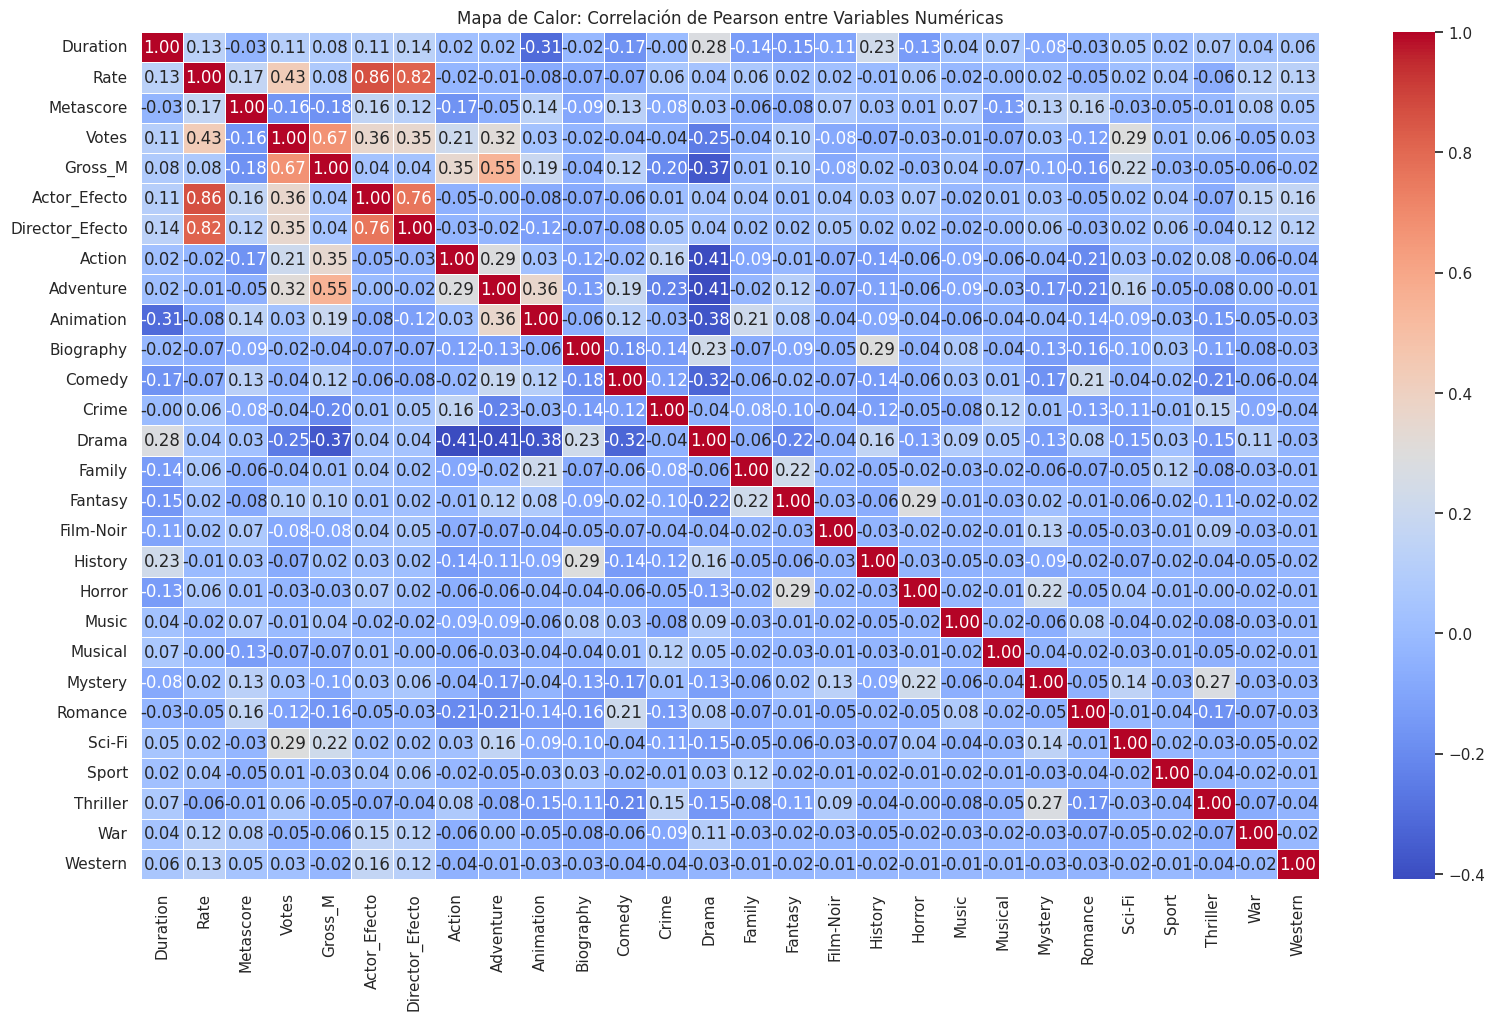

In [ ]:
# 5.1 Mapa de calor de correlación (Pearson)
matriz_correlacion = df_num.corr()

plt.figure(figsize=(19, 11))
sb.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación de Pearson entre Variables Numéricas')
plt.show()

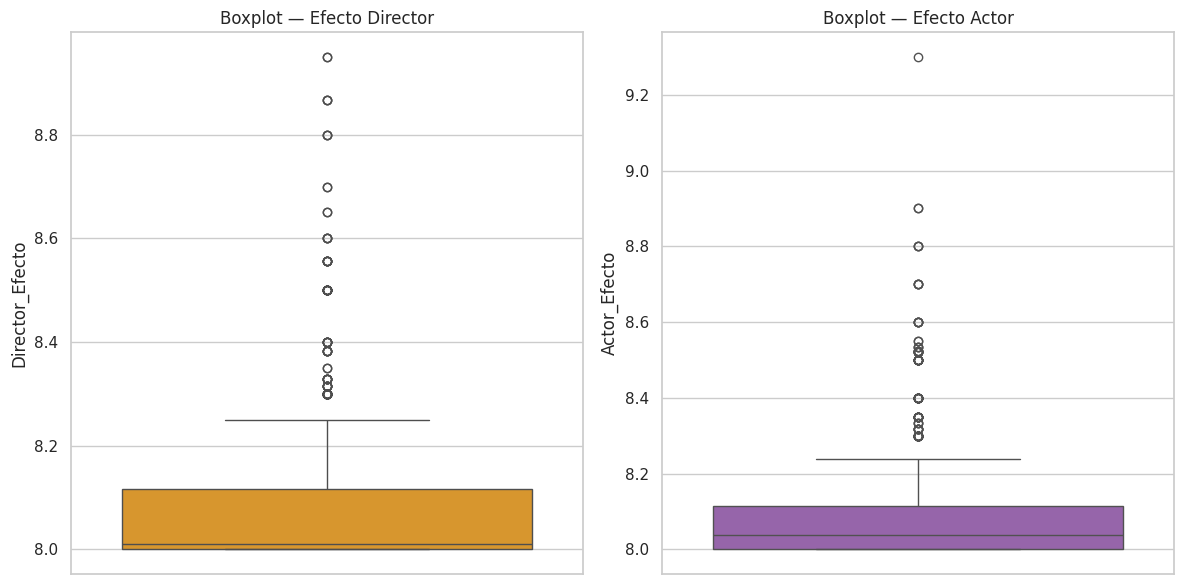

In [ ]:
# 5.2 Boxplots de las variables de efecto (detección de atípicos)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sb.boxplot(y=df['Director_Efecto'], color='#f39c12')
plt.title('Boxplot — Efecto Director')   # comentario corregido (antes decía Gross_M)

plt.subplot(1, 2, 2)
sb.boxplot(y=df['Actor_Efecto'], color='#9b59b6')
plt.title('Boxplot — Efecto Actor')

plt.tight_layout()
plt.show()

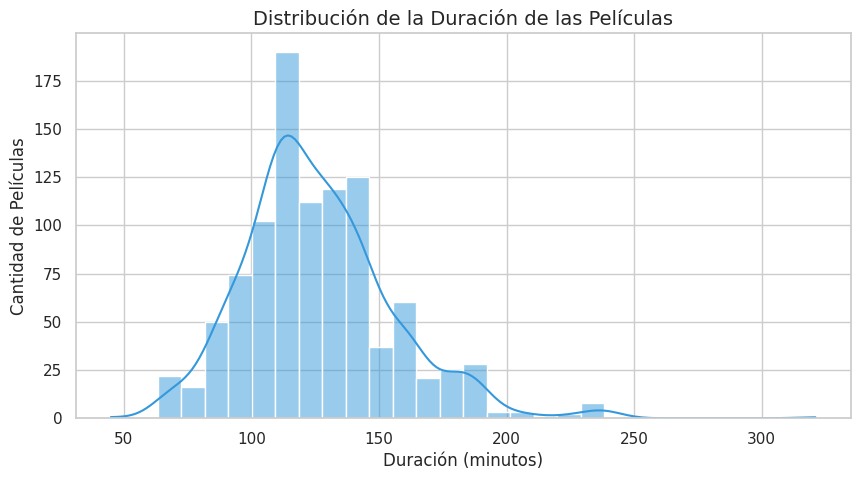

In [ ]:
# 5.3 Distribución de la duración
plt.figure(figsize=(10, 5))
sb.histplot(data=df, x='Duration', bins=30, kde=True, color='#3498db')
plt.title('Distribución de la Duración de las Películas', fontsize=14)
plt.xlabel('Duración (minutos)')
plt.ylabel('Cantidad de Películas')
plt.show()

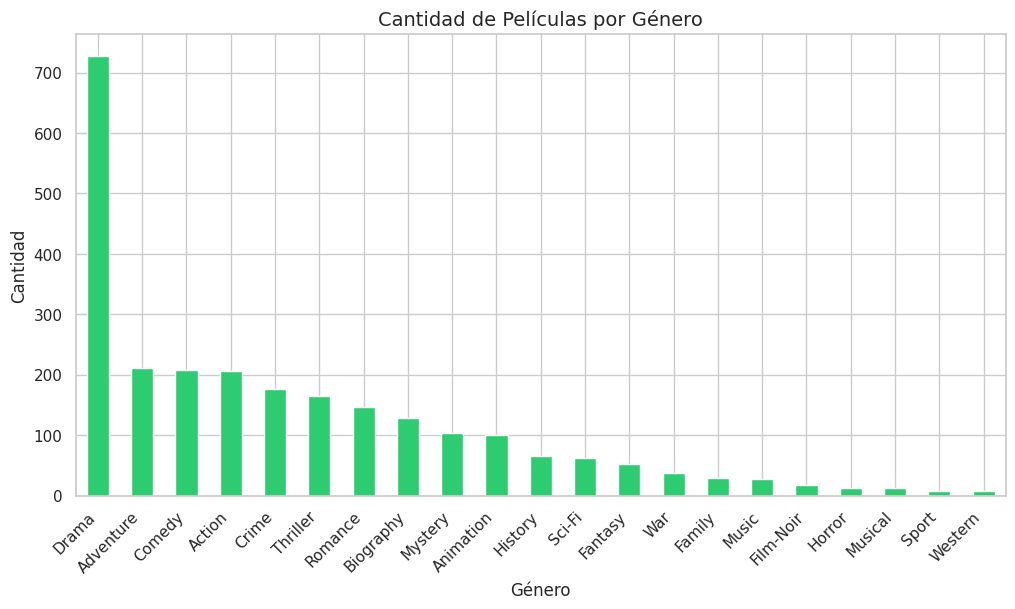

In [ ]:
# 5.4 Frecuencia de géneros
frecuencia_generos = df[df_genres.columns].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
frecuencia_generos.plot(kind='bar', color='#2ecc71')
plt.title('Cantidad de Películas por Género', fontsize=14)
plt.xlabel('Género'); plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.show()

## 6. Modelo v1 — Regresión Lineal Múltiple
Imputamos 'Gross_M' con la mediana del SET DE ENTRENAMIENTO (no del total),
para no filtrar información del test.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Variable objetivo y predictoras
y = df_num['Rate']
X = df_num.drop(columns=['Rate', 'Metascore'], errors='ignore')

# 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputación correcta: mediana calculada SOLO sobre el train
mediana_train = X_train.median()
X_train = X_train.fillna(mediana_train)
X_test  = X_test.fillna(mediana_train)

print("¿Nulos en X_train?:", X_train.isnull().sum().sum(), "(debe ser 0)")

¿Nulos en X_train?: 0 (debe ser 0)


In [ ]:
# Entrenamiento y evaluación — Regresión Lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)
pred_lineal = modelo_lineal.predict(X_test)

r2_lineal  = r2_score(y_test, pred_lineal)
mae_lineal = mean_absolute_error(y_test, pred_lineal)
mse_lineal = mean_squared_error(y_test, pred_lineal)

print("===== REGRESIÓN LINEAL MÚLTIPLE =====")
print(f"R²  : {r2_lineal:.4f}")
print(f"MAE : {mae_lineal:.4f}")
print(f"MSE : {mse_lineal:.4f}")

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Peso': modelo_lineal.coef_
}).sort_values(by='Peso', ascending=False)
print("\nTop 5 variables por peso:")
print(coeficientes.head(5).to_string(index=False))

===== REGRESIÓN LINEAL MÚLTIPLE =====
R²  : 0.7614
MAE : 0.0417
MSE : 0.0047

Top 5 variables por peso:
       Variable     Peso
   Actor_Efecto 0.587069
Director_Efecto 0.444291
         Horror 0.075412
         Family 0.047561
      Animation 0.020324


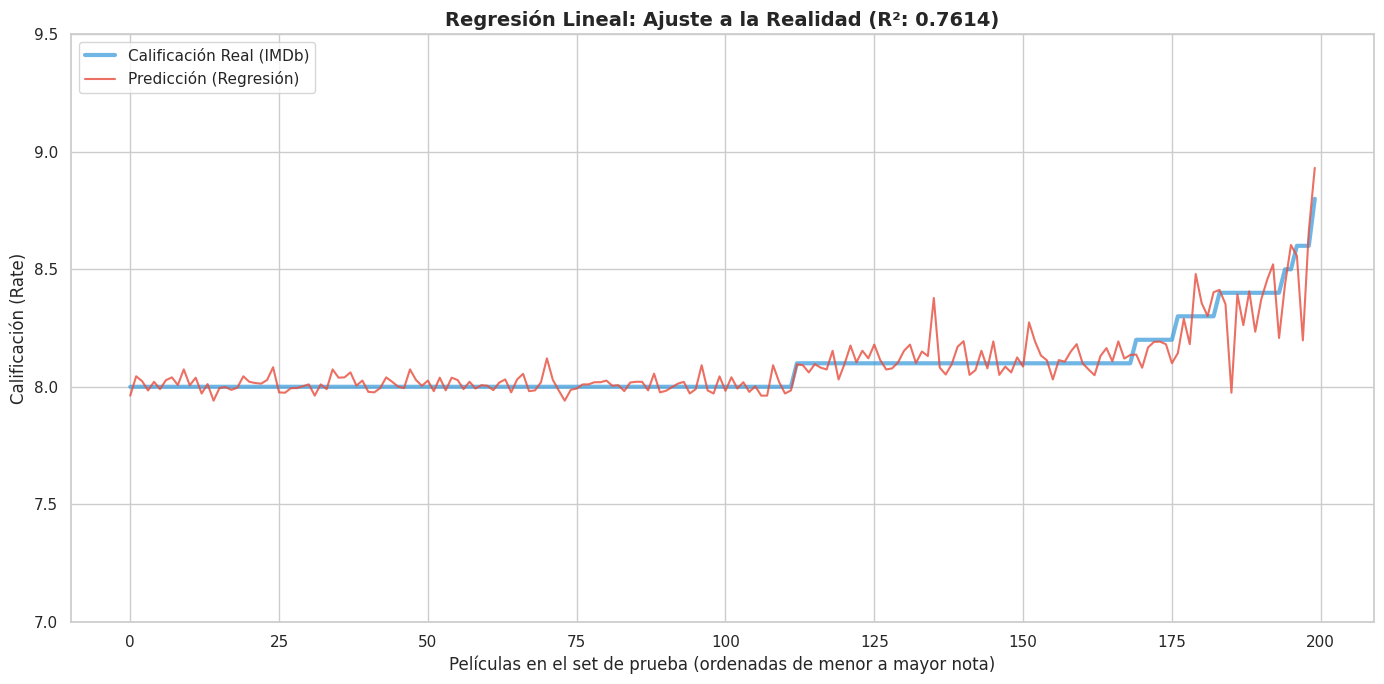

In [ ]:
# Gráfico de tendencia — Real vs Predicho (Regresión)
df_lineas = pd.DataFrame({'Real': y_test.values, 'Predicha': pred_lineal}) \
              .sort_values(by='Real').reset_index(drop=True)

plt.figure(figsize=(14, 7))
sb.set_theme(style="whitegrid")
plt.plot(df_lineas.index, df_lineas['Real'],     color='#3498db', label='Calificación Real (IMDb)', linewidth=3, alpha=0.7)
plt.plot(df_lineas.index, df_lineas['Predicha'], color='#e74c3c', label='Predicción (Regresión)',   linewidth=1.5, alpha=0.8)
plt.ylim(7.0, 9.5)
plt.title(f'Regresión Lineal: Ajuste a la Realidad (R²: {r2_lineal:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Películas en el set de prueba (ordenadas de menor a mayor nota)')
plt.ylabel('Calificación (Rate)')
plt.legend(loc='upper left')
plt.tight_layout(); plt.show()

## 7. Modelo v1 — Árbol de Decisión

In [ ]:
modelo_arbol = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_arbol.fit(X_train, y_train)
pred_arbol = modelo_arbol.predict(X_test)

r2_arbol  = r2_score(y_test, pred_arbol)
mae_arbol = mean_absolute_error(y_test, pred_arbol)

print("===== ÁRBOL DE DECISIÓN =====")
print(f"R²  : {r2_arbol:.4f}")
print(f"MAE : {mae_arbol:.4f}")

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_arbol.feature_importances_
}).sort_values(by='Importancia', ascending=False)
print("\nTop 5 variables por importancia:")
print(importancias.head(5).to_string(index=False))

===== ÁRBOL DE DECISIÓN =====
R²  : 0.7324
MAE : 0.0274

Top 5 variables por importancia:
       Variable  Importancia
   Actor_Efecto     0.574165
Director_Efecto     0.258338
          Votes     0.128014
        Gross_M     0.016945
       Duration     0.015736


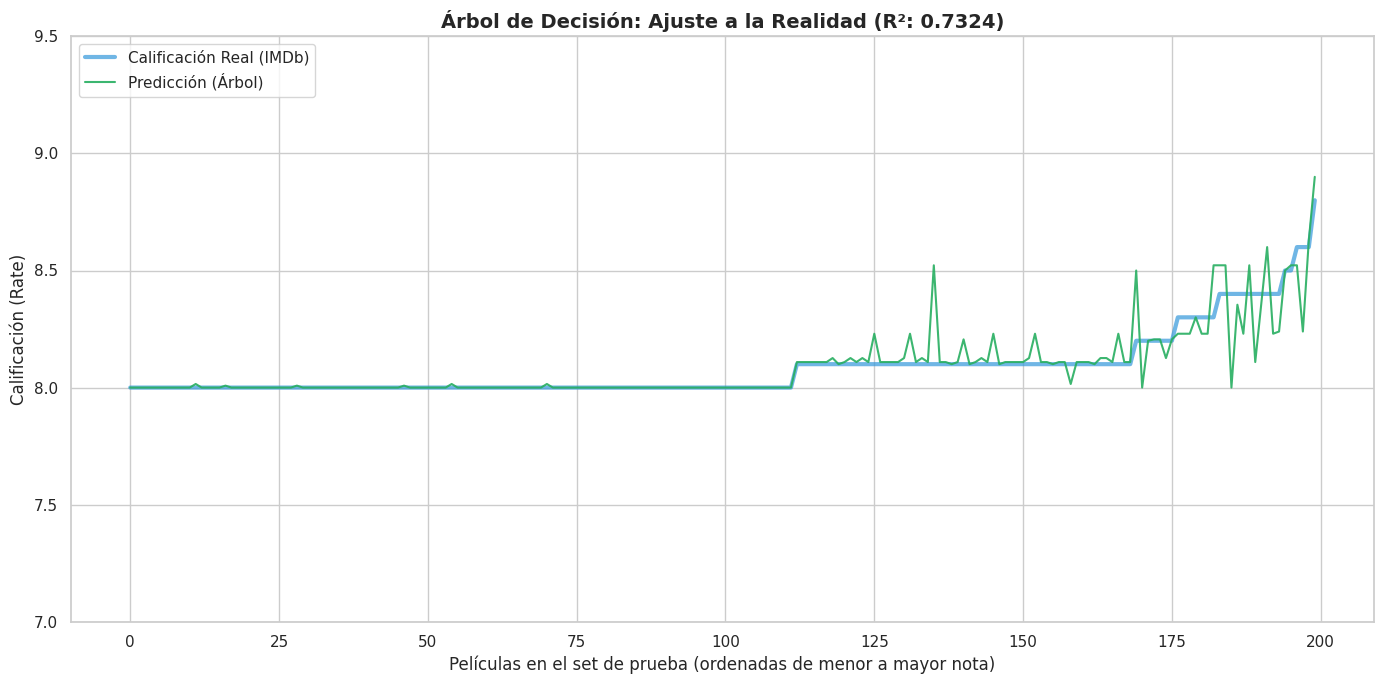

In [ ]:
# Gráfico de tendencia — Real vs Predicho (Árbol)
df_lineas_arbol = pd.DataFrame({'Real': y_test.values, 'Predicha': pred_arbol}) \
                    .sort_values(by='Real').reset_index(drop=True)

plt.figure(figsize=(14, 7))
sb.set_theme(style="whitegrid")
plt.plot(df_lineas_arbol.index, df_lineas_arbol['Real'],     color='#3498db', label='Calificación Real (IMDb)', linewidth=3, alpha=0.7)
plt.plot(df_lineas_arbol.index, df_lineas_arbol['Predicha'], color='#27ae60', label='Predicción (Árbol)',       linewidth=1.5, alpha=0.9)
plt.ylim(7.0, 9.5)
plt.title(f'Árbol de Decisión: Ajuste a la Realidad (R²: {r2_arbol:.4f})', fontsize=14, fontweight='bold')
plt.xlabel('Películas en el set de prueba (ordenadas de menor a mayor nota)')
plt.ylabel('Calificación (Rate)')
plt.legend(loc='upper left')
plt.tight_layout(); plt.show()